### K-Means

#### Dipersiapkan oleh : Alexander Ricky

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [48]:
df = pd.read_excel ("nba_baru.xlsx")
df

,Unnamed: 0,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Salarymissing,Collegemissing
0,0,Avery Bradley,Boston Celtics,0,PG,25,74,180,Texas,7730337,False,False
1,1,Jae Crowder,Boston Celtics,99,SF,25,78,235,Marquette,6796117,False,False
2,2,John Holland,Boston Celtics,30,SG,27,77,205,Boston University,2839073,True,False
3,3,R.J. Hunter,Boston Celtics,28,SG,22,77,185,Georgia State,1148640,False,False
4,4,Jonas Jerebko,Boston Celtics,8,PF,29,82,231,Kentucky,5000000,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
452,452,Trey Lyles,Utah Jazz,41,PF,20,82,234,Kentucky,2239800,False,False
453,453,Shelvin Mack,Utah Jazz,8,PG,26,75,203,Butler,2433333,False,False
454,454,Raul Neto,Utah Jazz,25,PG,24,73,179,Kentucky,900000,False,True
455,455,Tibor Pleiss,Utah Jazz,21,C,26,87,256,Kentucky,2900000,False,True


In [51]:
features = ["Age", "Height", "Weight", "Salary"]

data = df[features].copy()
data

,Age,Height,Weight,Salary
0,25,74,180,7730337
1,25,78,235,6796117
2,27,77,205,2839073
3,22,77,185,1148640
4,29,82,231,5000000
...,...,...,...,...
452,20,82,234,2239800
453,26,75,203,2433333
454,24,73,179,900000
455,26,87,256,2900000


In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(data)
data = pd.DataFrame(data, columns =features)
data

,Age,Height,Weight,Salary
0,-0.440701,-1.513808,-1.576454,0.567950
1,-0.440701,-0.347180,0.511666,0.387224
2,0.013927,-0.638837,-0.627308,-0.378272
3,-1.122644,-0.638837,-1.386625,-0.705289
4,0.468556,0.819448,0.359803,0.039763
...,...,...,...,...
452,-1.577273,0.819448,0.473701,-0.494202
453,-0.213387,-1.222151,-0.703240,-0.456763
454,-0.668016,-1.805465,-1.614420,-0.753388
455,-0.213387,2.277733,1.308949,-0.366486


In [94]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init = 'auto', max_iter = 300)
y_kmeans= kmeans.fit_predict(data)

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [53]:
kmeans.cluster_centers_

array([[2.61023891e+01, 7.91228669e+01, 2.19597270e+02, 1.73461734e+06],
       [2.80923077e+01, 7.97692308e+01, 2.30384615e+02, 1.56337473e+07],
       [2.86565657e+01, 7.90101010e+01, 2.21404040e+02, 6.73364099e+06]])

In [68]:
kl = KneeLocator(range(1,7), sse, curve = 'convex', direction = 'decreasing')

In [91]:
kl.elbow

np.int64(2)

In [54]:
kmeans.n_iter_

5

In [55]:
kmeans.labels_

array([2, 2, 0, 0, 2, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 1, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 2, 0,
       2, 1, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 1, 0, 1, 1, 2, 0, 0, 0,
       0, 1, 0, 0, 0, 2, 0, 2, 1, 0, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 2, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 1, 0, 0, 1, 2, 0, 0, 2, 0, 0, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 1, 0, 1, 0, 0, 2, 1, 1, 0, 0, 0, 0, 1, 0,
       2, 2, 2, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 2, 2, 0, 0, 0,
       2, 1, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1,
       1, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 2, 1, 0, 0, 2,
       2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 0,
       0, 1, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 2, 2, 0, 2,

In [82]:
silhouette_coefficients

[0.30099421263471565,
 0.3083236907597418,
 0.30914569179411217,
 0.30448283775715795,
 0.2904486790673941]

In [95]:
for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=42
    )

    kmeans.fit(data)

    score = silhouette_score(data_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

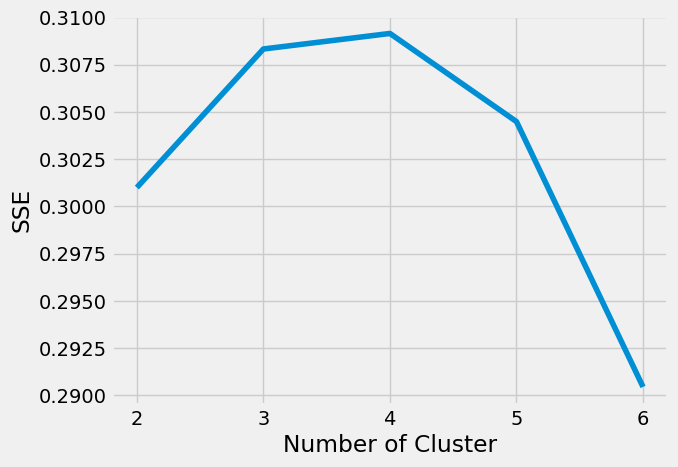

In [83]:
plt.style.use("fivethirtyeight")
plt.plot(range(2,7), silhouette_coefficients)
plt.xticks(range(2,7))
plt.xlabel("Number of Cluster")
plt.ylabel("SSE")
plt.show()

In [88]:
X = data.iloc[:,:].values
kmeans = KMeans(n_clusters = 2, random_state = 0, n_init='auto',max_iter=300)
y_kmeans=kmeans.fit(X).labels_

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


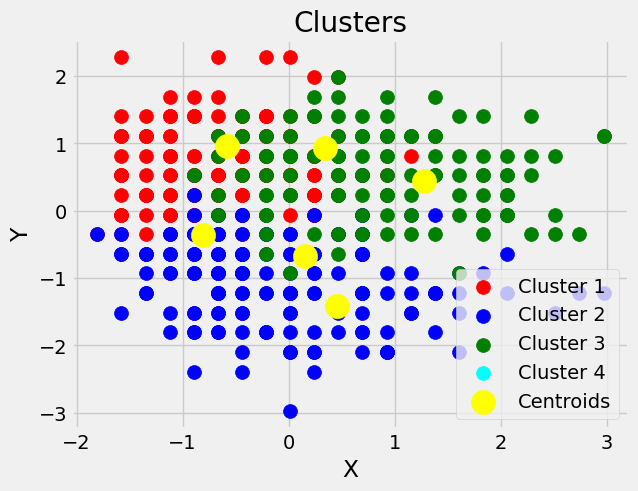

In [96]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
#plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.savefig("Cluster contoh.png")
plt.show()